# Priorisation actionnable des détections navales — scoring analyste v2

Ce notebook reconstruit une base propre et réutilisable pour le sujet **Chasse aux navires de guerre**.

## Objectif

Transformer les fichiers de base :

- `annotations_large.json`
- `detection_results.csv`
- `images_metadata_large.csv`
- `military_zones.csv`

en une chaîne actionnable :

```text
données brutes
→ validation
→ enrichissement géographique
→ scoring analyste
→ alertes à revue humaine
→ synthèses par zone/date
→ carte HTML interactive
```

## Positionnement métier

Le score ne mesure pas une menace réelle.  
Il sert à **prioriser l'analyse humaine** : faire remonter les observations où un navire de combat, de soutien ou un navire civil atypique apparaît dans ou près d'une zone sensible.

Limites assumées :

- les coordonnées disponibles localisent l'image ou la zone, pas le navire exact ;
- il n'y a pas d'identifiant stable de navire, donc pas de tracking individuel certain ;
- la notion de “rencontre” ou de “présence prolongée” est traitée comme un **proxy zone/date**, à vérifier par un analyste.

## 0 — Configuration

La cellule suivante est pensée pour fonctionner :

- dans ce dossier de travail ;
- dans un repo GitHub avec `data/raw/` ;
- dans l'environnement `/mnt/data` utilisé ici.

Les exports sont écrits dans `outputs_priorisation_v2/`.

In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

REQUIRED_FILES = [
    "annotations_large.json",
    "detection_results.csv",
    "images_metadata_large.csv",
    "military_zones.csv",
]

candidate_dirs = [
    Path("data/raw"),
    Path("../data/raw"),
    Path("."),
    Path("Sujet5/Généralisation"),
    Path("../Sujet5/Généralisation"),
    Path("/mnt/data"),
]

DATA_DIR = None
for candidate in candidate_dirs:
    if all((candidate / f).exists() for f in REQUIRED_FILES):
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Impossible de trouver les fichiers de base. "
        "Placez-les dans data/raw/, dans le dossier courant, ou adaptez DATA_DIR."
    )

OUTPUT_DIR = Path("outputs_priorisation_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SCORING_VERSION = "v2.1-actionnable"
REVIEW_THRESHOLD = 60  # seuil standard d'alerte analyste ; des exceptions métier peuvent aussi déclencher une revue

print(f"DATA_DIR   = {DATA_DIR.resolve()}")
print(f"OUTPUT_DIR = {OUTPUT_DIR.resolve()}")
print(f"Version scoring = {SCORING_VERSION}")

DATA_DIR   = /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/data/raw
OUTPUT_DIR = /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2
Version scoring = v2.1-actionnable


## 1 — Chargement des données de base

In [2]:
detections = pd.read_csv(DATA_DIR / "detection_results.csv")
images = pd.read_csv(DATA_DIR / "images_metadata_large.csv")
military_zones = pd.read_csv(DATA_DIR / "military_zones.csv")

with open(DATA_DIR / "annotations_large.json", "r", encoding="utf-8") as f:
    coco = json.load(f)

print("Fichiers chargés.")
print(f"detection_results.csv      : {detections.shape[0]} lignes, {detections.shape[1]} colonnes")
print(f"images_metadata_large.csv  : {images.shape[0]} lignes, {images.shape[1]} colonnes")
print(f"military_zones.csv         : {military_zones.shape[0]} lignes, {military_zones.shape[1]} colonnes")
print(f"annotations_large.json     : {len(coco.get('images', []))} images COCO, {len(coco.get('annotations', []))} annotations, {len(coco.get('categories', []))} catégories")

Fichiers chargés.
detection_results.csv      : 256 lignes, 11 colonnes
images_metadata_large.csv  : 100 lignes, 15 colonnes
military_zones.csv         : 20 lignes, 8 colonnes
annotations_large.json     : 100 images COCO, 256 annotations, 13 catégories


In [3]:
display(detections.head(3))
display(images.head(3))
display(military_zones.head(3))

,detection_id,image_id,file_name,timestamp,bbox,category,confidence,is_military,zone_id,zone_name,risk_level
0,DET-000-00001,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3766847153545144,0.602830810224785,0.2798675...",Navire de guerre,0.84,True,ZONE-002,Base navale de Norfolk,High
1,DET-000-00002,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.6730405409693083,0.37685587994514613,0.29411...",Navire civil,0.72,False,ZONE-002,Base navale de Norfolk,High
2,DET-000-00003,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3499607760017571,0.6063398574692226,0.244706...",Bâtiment de débarquement,0.96,False,ZONE-002,Base navale de Norfolk,High


,image_id,file_name,date,time,zone_id,zone_name,coordinates,country,risk_level,resolution,source,num_ships,ship_types,cloud_cover,url
0,IMG-000,satellite_000.jpg,2026-08-31,17:17:58,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...
1,IMG-001,satellite_001.jpg,2026-04-17,04:54:56,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,10m,Maxar,2,"Destroyer, Navire de guerre",39.0,https://example.com/satellite_images/satellite...
2,IMG-002,satellite_002.jpg,2026-03-02,15:20:53,ZONE-009,Base navale de Yokosuka,"35.4,139.7",Japan,High,1m,Sentinel-2,4,"Navire de soutien, Chalutier, Porte-avions, Na...",25.6,https://example.com/satellite_images/satellite...


,zone_id,name,coordinates,country,risk_level,description,base_name,active
0,MIL-000,Zone militaire 1 - Port de Singapour,"1.3,103.8",Singapore,Critical,Zone militaire stratégique près de Port de Sin...,Base Sous-marine 1,False
1,MIL-001,Zone militaire 2 - Port de Shanghai,"31.2,121.5",China,Critical,Zone militaire stratégique près de Port de Sha...,Base Navale 2,True
2,MIL-002,Zone militaire 3 - Port de Shanghai,"31.2,121.5",China,Critical,Zone militaire stratégique près de Port de Sha...,Base Navale 3,True


## 2 — Validation rapide et points de vigilance

Ici on vérifie les points qui peuvent casser ou biaiser la suite :

1. colonnes obligatoires ;
2. doublons d'identifiants ;
3. cohérence entre détections et métadonnées ;
4. incompatibilité volontaire entre les `zone_id` des détections (`ZONE-XXX`) et des zones militaires (`MIL-XXX`) ;
5. qualité des bounding boxes.

In [4]:
REQUIRED_DETECTION_COLUMNS = {
    "detection_id", "image_id", "file_name", "timestamp", "bbox",
    "category", "confidence", "is_military", "zone_id", "zone_name", "risk_level"
}
REQUIRED_IMAGE_COLUMNS = {
    "image_id", "file_name", "date", "time", "zone_id", "zone_name",
    "coordinates", "country", "risk_level", "resolution", "source",
    "num_ships", "ship_types", "cloud_cover", "url"
}
REQUIRED_ZONE_COLUMNS = {
    "zone_id", "name", "coordinates", "country", "risk_level",
    "description", "base_name", "active"
}

def check_required_columns(df, required, name):
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{name} : colonnes manquantes : {missing}")
    print(f"{name} : colonnes obligatoires OK")

check_required_columns(detections, REQUIRED_DETECTION_COLUMNS, "detection_results.csv")
check_required_columns(images, REQUIRED_IMAGE_COLUMNS, "images_metadata_large.csv")
check_required_columns(military_zones, REQUIRED_ZONE_COLUMNS, "military_zones.csv")

assert detections["detection_id"].is_unique, "detection_id contient des doublons"
assert images["image_id"].is_unique, "image_id contient des doublons dans images_metadata_large.csv"

unknown_images = set(detections["image_id"]) - set(images["image_id"])
if unknown_images:
    raise ValueError(f"Certaines détections référencent des images absentes des métadonnées : {sorted(unknown_images)[:5]}")
print("Relations image_id : OK")

zone_id_intersection = set(detections["zone_id"]) & set(military_zones["zone_id"])
print(f"Intersection des zone_id detection/military_zones : {zone_id_intersection}")
if len(zone_id_intersection) == 0:
    print("Point de vigilance confirmé : ne pas joindre detection_results et military_zones par zone_id.")
    print("La jointure principale utilisera zone_name ↔ lieu extrait de military_zones.name.")

detection_results.csv : colonnes obligatoires OK
images_metadata_large.csv : colonnes obligatoires OK
military_zones.csv : colonnes obligatoires OK
Relations image_id : OK
Intersection des zone_id detection/military_zones : set()
Point de vigilance confirmé : ne pas joindre detection_results et military_zones par zone_id.
La jointure principale utilisera zone_name ↔ lieu extrait de military_zones.name.


In [5]:
# Audit bounding boxes : format x,y,w,h normalisé
bbox_parts = detections["bbox"].astype(str).str.split(",", expand=True).iloc[:, :4].apply(pd.to_numeric, errors="coerce")
bbox_parts.columns = ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]

bbox_in_0_1 = bbox_parts.apply(lambda col: col.between(0, 1).all()).to_dict()
bbox_exceeds_image = ((bbox_parts["bbox_x"] + bbox_parts["bbox_w"]) > 1) | ((bbox_parts["bbox_y"] + bbox_parts["bbox_h"]) > 1)

print("Coordonnées bbox entre 0 et 1 :", bbox_in_0_1)
print(f"Bboxes qui dépassent potentiellement l'image : {bbox_exceeds_image.sum()} / {len(detections)}")

Coordonnées bbox entre 0 et 1 : {'bbox_x': True, 'bbox_y': True, 'bbox_w': True, 'bbox_h': True}
Bboxes qui dépassent potentiellement l'image : 10 / 256


## 3 — Référentiels métier

On stabilise ici la définition des groupes de navires et l'ordre des niveaux de risque.

Cette classification évite de dépendre aveuglément du champ `is_military` fourni : on conserve ce champ comme information source, mais on ajoute une classification explicite pour le scoring.

In [6]:
RISK_ORDER = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
RISK_POINTS = {"Low": 0, "Medium": 6, "High": 12, "Critical": 18}

BASE_ORDER = {
    "Base Aérienne": 1,
    "Base Navale": 2,
    "Base Sous-marine": 3,
}

STRATEGIC_COMBAT_CLASSES = {
    "Porte-avions",
    "Sous-marin",
    "Destroyer",
    "Croiseur",
}

COMBAT_CLASSES = STRATEGIC_COMBAT_CLASSES | {
    "Frégate",
    "Corvette",
    "Navire de guerre",
}

SUPPORT_OR_AMPHIBIOUS_CLASSES = {
    "Bâtiment de débarquement",
    "Navire de soutien",
}

CIVILIAN_CLASSES = {
    "Navire civil",
    "Cargo",
    "Pétrolier",
    "Chalutier",
    "Porte-conteneurs",
}

ALERT_ORDER = {
    "Veille": 0,
    "À examiner": 1,
    "Alerte analyste": 2,
    "Revue prioritaire immédiate": 3,
}

def vessel_group(category: str) -> str:
    if category in STRATEGIC_COMBAT_CLASSES:
        return "combat_strategique"
    if category in COMBAT_CLASSES:
        return "combat"
    if category in SUPPORT_OR_AMPHIBIOUS_CLASSES:
        return "soutien_ou_amphibie"
    if category in CIVILIAN_CLASSES:
        return "civil"
    return "autre"

def max_risk_value(values):
    clean_values = [v for v in values if pd.notna(v)]
    if not clean_values:
        return np.nan
    return max(clean_values, key=lambda r: RISK_ORDER.get(str(r), 0))

def max_alert_value(values):
    clean_values = [v for v in values if pd.notna(v)]
    if not clean_values:
        return np.nan
    return max(clean_values, key=lambda a: ALERT_ORDER.get(str(a), 0))

print("Groupes de navires disponibles :")
print(pd.Series(detections["category"].map(vessel_group)).value_counts().to_string())

Groupes de navires disponibles :
category
civil                  84
combat_strategique     71
combat                 63
soutien_ou_amphibie    38


## 4 — Fonctions utilitaires

Ces fonctions sont volontairement réutilisables : elles pourront être déplacées plus tard dans `src/geo.py`, `src/scoring.py` ou utilisées dans une app interactive.

In [7]:
def parse_coordinates(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    """Parse une colonne 'latitude,longitude' en deux séries numériques."""
    coords = series.astype(str).str.split(",", expand=True)
    if coords.shape[1] < 2:
        return pd.Series([np.nan] * len(series)), pd.Series([np.nan] * len(series))
    lat = pd.to_numeric(coords[0], errors="coerce")
    lon = pd.to_numeric(coords[1], errors="coerce")
    return lat, lon

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    """Distance en kilomètres entre deux points GPS."""
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan

    radius_earth_km = 6371.0088
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    d_phi = math.radians(lat2 - lat1)
    d_lambda = math.radians(lon2 - lon1)

    a = (
        math.sin(d_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2) ** 2
    )
    return 2 * radius_earth_km * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def risk_max(a, b):
    """Retourne le niveau de risque le plus élevé entre deux valeurs."""
    if pd.isna(a):
        return b
    if pd.isna(b):
        return a
    return a if RISK_ORDER.get(str(a), 0) >= RISK_ORDER.get(str(b), 0) else b

def resolution_factor(resolution_m):
    """Score normalisé de qualité de résolution : 1 est meilleur."""
    if pd.isna(resolution_m):
        return 0.5
    if resolution_m <= 0.5:
        return 1.0
    if resolution_m <= 1.0:
        return 0.9
    if resolution_m <= 3.0:
        return 0.7
    if resolution_m <= 10.0:
        return 0.4
    return 0.2

## 5 — Préparation des métadonnées images

On extrait :

- latitude / longitude de l'image ou de la zone ;
- date complète ;
- résolution numérique en mètres ;
- couverture nuageuse.

In [8]:
images_ref = images.copy()

images_ref["image_lat"], images_ref["image_lon"] = parse_coordinates(images_ref["coordinates"])
images_ref["image_datetime"] = pd.to_datetime(
    images_ref["date"].astype(str) + " " + images_ref["time"].astype(str),
    errors="coerce",
    utc=True,
)
images_ref["date_only"] = images_ref["image_datetime"].dt.date
images_ref["resolution_m"] = pd.to_numeric(
    images_ref["resolution"].astype(str).str.replace("m", "", regex=False),
    errors="coerce",
)
images_ref["cloud_cover"] = pd.to_numeric(images_ref["cloud_cover"], errors="coerce").clip(0, 100)

display(images_ref[[
    "image_id", "file_name", "image_datetime", "zone_name",
    "image_lat", "image_lon", "resolution", "resolution_m", "cloud_cover"
]].head())

,image_id,file_name,image_datetime,zone_name,image_lat,image_lon,resolution,resolution_m,cloud_cover
0,IMG-000,satellite_000.jpg,2026-08-31 17:17:58+00:00,Base navale de Norfolk,36.9,-76.3,1m,1.0,17.0
1,IMG-001,satellite_001.jpg,2026-04-17 04:54:56+00:00,Base navale de Norfolk,36.9,-76.3,10m,10.0,39.0
2,IMG-002,satellite_002.jpg,2026-03-02 15:20:53+00:00,Base navale de Yokosuka,35.4,139.7,1m,1.0,25.6
3,IMG-003,satellite_003.jpg,2026-08-17 16:27:15+00:00,Détroit d'Ormuz,25.0,56.0,0.5m,0.5,27.3
4,IMG-004,satellite_004.jpg,2026-10-03 08:53:49+00:00,Mer Baltique,55.0,20.0,1m,1.0,32.7


## 6 — Préparation des zones militaires et sensibles

Le fichier `military_zones.csv` peut contenir plusieurs entrées pour un même lieu.

On agrège donc par lieu :

- risque maximum ;
- zone active si au moins une entrée est active ;
- type de base le plus sensible ;
- densité militaire, c'est-à-dire nombre d'entrées associées au lieu.

In [9]:
zones_ref = military_zones.copy()

zones_ref["location_name"] = zones_ref["name"].str.extract(
    r"Zone militaire\s+\d+\s+-\s+(.+)$",
    expand=False,
)
zones_ref["location_name"] = zones_ref["location_name"].fillna(zones_ref["name"])

zones_ref["mil_zone_lat"], zones_ref["mil_zone_lon"] = parse_coordinates(zones_ref["coordinates"])
zones_ref["base_type"] = zones_ref["base_name"].str.extract(
    r"(Base Sous-marine|Base Navale|Base Aérienne)",
    expand=False,
)

def aggregate_military_zone(group: pd.DataFrame) -> pd.Series:
    risk = max_risk_value(group["risk_level"].astype(str).tolist())
    active = group["active"].fillna(False).astype(bool).any()

    base_candidates = group["base_type"].dropna().tolist()
    base_type = (
        max(base_candidates, key=lambda b: BASE_ORDER.get(b, 0))
        if base_candidates else np.nan
    )

    return pd.Series({
        "mil_risk_level": risk,
        "mil_zone_active": bool(active),
        "base_type": base_type,
        "mil_density": len(group),
        "mil_zone_lat": group["mil_zone_lat"].mean(),
        "mil_zone_lon": group["mil_zone_lon"].mean(),
        "mil_zone_ids": ";".join(group["zone_id"].astype(str).tolist()),
        "mil_base_names": ";".join(group["base_name"].astype(str).tolist()),
    })

try:
    zones_agg = (
        zones_ref
        .groupby("location_name")
        .apply(aggregate_military_zone, include_groups=False)
        .reset_index()
    )
except TypeError:
    zones_agg = (
        zones_ref
        .groupby("location_name")
        .apply(aggregate_military_zone)
        .reset_index()
    )

display(zones_agg.sort_values(["mil_risk_level", "mil_density"], ascending=[False, False]))

,location_name,mil_risk_level,mil_zone_active,base_type,mil_density,mil_zone_lat,mil_zone_lon,mil_zone_ids,mil_base_names
1,Base navale de Rota,High,False,Base Sous-marine,1,36.60,-6.4,MIL-014,Base Sous-marine 15
2,Canal de Suez,High,False,Base Aérienne,1,30.00,32.5,MIL-012,Base Aérienne 13
4,Détroit de Malacca,High,False,Base Sous-marine,1,3.00,101.0,MIL-015,Base Sous-marine 16
5,Golfe Persique,High,False,Base Sous-marine,1,26.00,55.0,MIL-009,Base Sous-marine 10
6,Port de Busan,High,False,Base Sous-marine,1,35.10,129.0,MIL-006,Base Sous-marine 7
7,Port de Shanghai,Critical,True,Base Sous-marine,5,31.20,121.5,MIL-001;MIL-002;MIL-008;MIL-016;MIL-018,Base Navale 2;Base Navale 3;Base Aérienne 9;Ba...
0,Base navale de Pearl Harbor,Critical,True,Base Sous-marine,4,21.40,-157.9,MIL-004;MIL-005;MIL-017;MIL-019,Base Aérienne 5;Base Navale 6;Base Sous-marine...
9,Port militaire de Toulon,Critical,True,Base Navale,3,43.12,5.9,MIL-003;MIL-007;MIL-010,Base Navale 4;Base Aérienne 8;Base Aérienne 11
3,Détroit d'Ormuz,Critical,True,Base Sous-marine,2,25.00,56.0,MIL-011;MIL-013,Base Sous-marine 12;Base Sous-marine 14
8,Port de Singapour,Critical,False,Base Sous-marine,1,1.30,103.8,MIL-000,Base Sous-marine 1


In [10]:
print("Zones présentes dans detection_results mais absentes de military_zones :")
zones_det = set(detections["zone_name"].unique())
zones_mil = set(zones_agg["location_name"].unique())
print(sorted(zones_det - zones_mil))

print("\nCes zones ne sont pas ignorées : leur risk_level reste utilisé via les métadonnées/détections.")

Zones présentes dans detection_results mais absentes de military_zones :
['Base navale de Norfolk', 'Base navale de Yokosuka', 'Mer Baltique', 'Mer de Chine Méridionale', 'Port de Rotterdam']

Ces zones ne sont pas ignorées : leur risk_level reste utilisé via les métadonnées/détections.


## 7 — Enrichissement géographique des détections

On construit la table de travail principale.

Choix méthodologique important :

- `risk_level` issu des détections/métadonnées décrit la sensibilité de la zone observée ;
- `mil_risk_level` décrit le référentiel des zones militaires connues ;
- `effective_risk_level` retient le plus élevé des deux, pour éviter de sous-estimer une zone sensible non listée dans `military_zones.csv`.

In [11]:
scored = detections.copy()

# On garde le champ source, mais on ne l'utilise pas comme seule vérité métier.
scored = scored.rename(columns={
    "is_military": "is_military_source",
    "risk_level": "detection_risk_level",
})

metadata_cols = [
    "image_id", "date", "time", "date_only", "image_datetime",
    "coordinates", "image_lat", "image_lon", "country", "risk_level",
    "resolution", "resolution_m", "source", "num_ships", "ship_types",
    "cloud_cover", "url",
]

scored = scored.merge(
    images_ref[metadata_cols],
    on="image_id",
    how="left",
)
scored = scored.rename(columns={
    "coordinates": "image_coordinates",
    "risk_level": "metadata_risk_level",
})

scored = scored.merge(
    zones_agg,
    left_on="zone_name",
    right_on="location_name",
    how="left",
)

scored["in_sensitive_military_zone"] = scored["location_name"].notna()
scored["effective_risk_level"] = [
    risk_max(a, b)
    for a, b in zip(scored["detection_risk_level"], scored["mil_risk_level"])
]

print(f"Lignes enrichies : {len(scored)}")
print(f"Détections avec match direct dans military_zones : {scored['in_sensitive_military_zone'].sum()} / {len(scored)}")
display(scored[[
    "detection_id", "image_id", "category", "zone_name",
    "detection_risk_level", "mil_risk_level", "effective_risk_level",
    "in_sensitive_military_zone", "base_type", "mil_zone_active", "mil_density"
]].head())

Lignes enrichies : 256
Détections avec match direct dans military_zones : 135 / 256


,detection_id,image_id,category,zone_name,detection_risk_level,mil_risk_level,effective_risk_level,in_sensitive_military_zone,base_type,mil_zone_active,mil_density
0,DET-000-00001,IMG-000,Navire de guerre,Base navale de Norfolk,High,NaN,High,False,NaN,NaN,NaN
1,DET-000-00002,IMG-000,Navire civil,Base navale de Norfolk,High,NaN,High,False,NaN,NaN,NaN
2,DET-000-00003,IMG-000,Bâtiment de débarquement,Base navale de Norfolk,High,NaN,High,False,NaN,NaN,NaN
3,DET-000-00004,IMG-000,Destroyer,Base navale de Norfolk,High,NaN,High,False,NaN,NaN,NaN
4,DET-000-00005,IMG-000,Pétrolier,Base navale de Norfolk,High,NaN,High,False,NaN,NaN,NaN


## 8 — Distance à la zone sensible connue la plus proche

On utilise une vraie distance Haversine en kilomètres, et non une distance approximative en degrés.

Cette distance ne donne pas la position du navire : elle compare la coordonnée de l'image/zone observée avec le référentiel de zones sensibles.

In [12]:
def find_nearest_sensitive_zone(row: pd.Series, reference_zones: pd.DataFrame) -> pd.Series:
    lat = row["image_lat"]
    lon = row["image_lon"]

    if pd.isna(lat) or pd.isna(lon) or reference_zones.empty:
        return pd.Series({
            "nearest_sensitive_zone": np.nan,
            "nearest_sensitive_zone_distance_km": np.nan,
            "nearest_sensitive_zone_active": np.nan,
            "nearest_sensitive_zone_risk": np.nan,
        })

    distances = reference_zones.apply(
        lambda z: haversine_km(lat, lon, z["mil_zone_lat"], z["mil_zone_lon"]),
        axis=1,
    )
    nearest_idx = distances.idxmin()
    nearest_zone = reference_zones.loc[nearest_idx]

    return pd.Series({
        "nearest_sensitive_zone": nearest_zone["location_name"],
        "nearest_sensitive_zone_distance_km": distances.loc[nearest_idx],
        "nearest_sensitive_zone_active": nearest_zone["mil_zone_active"],
        "nearest_sensitive_zone_risk": nearest_zone["mil_risk_level"],
    })

nearest_info = scored.apply(lambda row: find_nearest_sensitive_zone(row, zones_agg), axis=1)
scored = pd.concat([scored, nearest_info], axis=1)

# Seuil conservateur. Pour le dataset fourni, les correspondances exactes sont souvent à 0 km.
PROXIMITY_THRESHOLD_KM = 25
scored["near_sensitive_zone_25km"] = scored["nearest_sensitive_zone_distance_km"] <= PROXIMITY_THRESHOLD_KM

display(scored[[
    "detection_id", "zone_name", "image_lat", "image_lon",
    "nearest_sensitive_zone", "nearest_sensitive_zone_distance_km",
    "near_sensitive_zone_25km"
]].head())

,detection_id,zone_name,image_lat,image_lon,nearest_sensitive_zone,nearest_sensitive_zone_distance_km,near_sensitive_zone_25km
0,DET-000-00001,Base navale de Norfolk,36.9,-76.3,Base navale de Rota,6076.454469,False
1,DET-000-00002,Base navale de Norfolk,36.9,-76.3,Base navale de Rota,6076.454469,False
2,DET-000-00003,Base navale de Norfolk,36.9,-76.3,Base navale de Rota,6076.454469,False
3,DET-000-00004,Base navale de Norfolk,36.9,-76.3,Base navale de Rota,6076.454469,False
4,DET-000-00005,Base navale de Norfolk,36.9,-76.3,Base navale de Rota,6076.454469,False


## 9 — Features navire, bbox et qualité d'observation

On sépare clairement :

- la **priorité opérationnelle** : intérêt pour l'analyste ;
- la **qualité d'observation** : fiabilité relative de l'information.

Une détection importante mais de qualité moyenne doit rester visible, avec une mention “à vérifier”.

In [13]:
# Groupes de navires
scored["vessel_group"] = scored["category"].map(vessel_group)
scored["is_combat_vessel"] = scored["vessel_group"].isin(["combat_strategique", "combat"])
scored["is_support_or_amphibious"] = scored["vessel_group"].eq("soutien_ou_amphibie")
scored["is_civilian_vessel"] = scored["vessel_group"].eq("civil")

# Bbox
bbox = scored["bbox"].astype(str).str.split(",", expand=True).iloc[:, :4].apply(pd.to_numeric, errors="coerce")
bbox.columns = ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]
scored = pd.concat([scored, bbox], axis=1)

scored["bbox_ratio"] = scored["bbox_w"] / scored["bbox_h"].replace(0, np.nan)
scored["bbox_area_pct"] = scored["bbox_w"] * scored["bbox_h"] * 100

scored["bbox_inside_image"] = (
    scored[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].notna().all(axis=1)
    & scored["bbox_x"].between(0, 1)
    & scored["bbox_y"].between(0, 1)
    & scored["bbox_w"].between(0, 1)
    & scored["bbox_h"].between(0, 1)
    & ((scored["bbox_x"] + scored["bbox_w"]) <= 1)
    & ((scored["bbox_y"] + scored["bbox_h"]) <= 1)
)

def bbox_plausibility(row: pd.Series) -> str:
    """Heuristique douce : ne remplace pas la validation visuelle."""
    ratio = row["bbox_ratio"]
    category = row["category"]

    if pd.isna(ratio):
        return "indeterminee"
    if not row["bbox_inside_image"]:
        return "bbox_hors_image"
    if category == "Sous-marin" and ratio < 2.5:
        return "a_verifier"
    if category == "Porte-avions" and ratio < 1.8:
        return "a_verifier"
    if category == "Chalutier" and ratio > 6.0:
        return "a_verifier"
    return "plausible"

scored["bbox_plausibility"] = scored.apply(bbox_plausibility, axis=1)
scored["classification_uncertainty_flag"] = scored["bbox_plausibility"].isin(["a_verifier", "bbox_hors_image", "indeterminee"])

# Confiance ajustée par la couverture nuageuse
scored["confidence"] = pd.to_numeric(scored["confidence"], errors="coerce")
scored["cloud_cover"] = pd.to_numeric(scored["cloud_cover"], errors="coerce").fillna(0).clip(0, 100)
scored["adjusted_confidence"] = (
    scored["confidence"] * (1 - scored["cloud_cover"] / 100)
).clip(0, 1)

# Quality score séparé du score de priorité
scored["resolution_factor"] = scored["resolution_m"].map(resolution_factor)
scored["bbox_quality_factor"] = scored["bbox_inside_image"].map({True: 1.0, False: 0.5})
scored.loc[scored["classification_uncertainty_flag"], "bbox_quality_factor"] = (
    scored.loc[scored["classification_uncertainty_flag"], "bbox_quality_factor"].clip(upper=0.7)
)

scored["quality_score"] = (
    100 * (
        0.70 * scored["adjusted_confidence"].fillna(0)
        + 0.20 * scored["resolution_factor"].fillna(0.5)
        + 0.10 * scored["bbox_quality_factor"].fillna(0.5)
    )
).round().clip(0, 100).astype(int)

scored["quality_level"] = pd.cut(
    scored["quality_score"],
    bins=[-1, 49, 74, 100],
    labels=["Faible", "Moyenne", "Bonne"],
)

display(scored[[
    "detection_id", "category", "vessel_group", "confidence",
    "cloud_cover", "adjusted_confidence", "resolution",
    "bbox_ratio", "bbox_plausibility", "quality_score", "quality_level"
]].head())

,detection_id,category,vessel_group,confidence,cloud_cover,adjusted_confidence,resolution,bbox_ratio,bbox_plausibility,quality_score,quality_level
0,DET-000-00001,Navire de guerre,combat,0.84,17.0,0.6972,1m,4.191431,plausible,77,Bonne
1,DET-000-00002,Navire civil,civil,0.72,17.0,0.5976,1m,1.246145,plausible,70,Moyenne
2,DET-000-00003,Bâtiment de débarquement,soutien_ou_amphibie,0.96,17.0,0.7968,1m,1.212964,plausible,84,Bonne
3,DET-000-00004,Destroyer,combat_strategique,0.89,17.0,0.7387,1m,2.169567,plausible,80,Bonne
4,DET-000-00005,Pétrolier,civil,0.90,17.0,0.7470,1m,0.519971,plausible,80,Bonne


## 10 — Contexte d'activité par image, zone et date

Sans `vessel_id`, on ne peut pas dire qu'un même navire est resté plusieurs jours.

En revanche, on peut créer des proxys utiles pour l'analyste :

- nombre de navires dans la même image ;
- nombre de détections dans la même zone le même jour ;
- co-présence potentielle de navires de combat et civils dans la même zone/jour ;
- nombre de jours d'observation par zone.

In [14]:
image_context = (
    scored
    .groupby("image_id")
    .agg(
        same_image_detection_count=("detection_id", "count"),
        same_image_combat_count=("is_combat_vessel", "sum"),
        same_image_civilian_count=("is_civilian_vessel", "sum"),
    )
    .reset_index()
)

zone_day_context = (
    scored
    .groupby(["zone_name", "date_only"])
    .agg(
        same_zone_day_detection_count=("detection_id", "count"),
        same_zone_day_combat_count=("is_combat_vessel", "sum"),
        same_zone_day_civilian_count=("is_civilian_vessel", "sum"),
    )
    .reset_index()
)

zone_time_context = (
    scored
    .groupby("zone_name")
    .agg(
        zone_first_observation=("image_datetime", "min"),
        zone_last_observation=("image_datetime", "max"),
        zone_observation_days=("date_only", "nunique"),
    )
    .reset_index()
)
zone_time_context["zone_observation_span_days"] = (
    zone_time_context["zone_last_observation"] - zone_time_context["zone_first_observation"]
).dt.days

scored = scored.merge(image_context, on="image_id", how="left")
scored = scored.merge(zone_day_context, on=["zone_name", "date_only"], how="left")
scored = scored.merge(zone_time_context, on="zone_name", how="left")

scored["possible_co_presence_proxy"] = (
    (scored["same_zone_day_combat_count"] >= 1)
    & (scored["same_zone_day_civilian_count"] >= 1)
    & (scored["same_zone_day_detection_count"] >= 2)
)

scored["dense_activity_same_day"] = scored["same_zone_day_detection_count"] >= 4

display(scored[[
    "detection_id", "zone_name", "date_only",
    "same_zone_day_detection_count", "same_zone_day_combat_count",
    "same_zone_day_civilian_count", "possible_co_presence_proxy",
    "zone_observation_days", "zone_observation_span_days"
]].head())

,detection_id,zone_name,date_only,same_zone_day_detection_count,same_zone_day_combat_count,same_zone_day_civilian_count,possible_co_presence_proxy,zone_observation_days,zone_observation_span_days
0,DET-000-00001,Base navale de Norfolk,2026-08-31,5,2,2,True,9,306
1,DET-000-00002,Base navale de Norfolk,2026-08-31,5,2,2,True,9,306
2,DET-000-00003,Base navale de Norfolk,2026-08-31,5,2,2,True,9,306
3,DET-000-00004,Base navale de Norfolk,2026-08-31,5,2,2,True,9,306
4,DET-000-00005,Base navale de Norfolk,2026-08-31,5,2,2,True,9,306


## 11 — Scoring analyste v2

Le score est sur 100 et reste volontairement explicable.

| Bloc | Maximum | Intuition |
|---|---:|---|
| Nature du navire | 30 | Les navires de combat stratégiques sont prioritaires |
| Sensibilité géographique | 25 | Zone critique, zone militaire connue, zone active |
| Contexte local | 20 | Base sensible, densité militaire, activité dense, co-présence |
| Confiance observationnelle | 15 | Confiance ajustée par les nuages |
| Anomalies métier | 10 | Civil en zone sensible, combat hors zone militaire connue mais zone à risque |

Le `quality_score` reste séparé : une observation peut être prioritaire mais à vérifier visuellement.

In [15]:
def risk_points(risk_level) -> int:
    return RISK_POINTS.get(str(risk_level), 0)

def compute_score_parts(row: pd.Series) -> pd.Series:
    # A. Nature du navire — 0 à 30
    if row["category"] in STRATEGIC_COMBAT_CLASSES:
        score_vessel = 30
    elif row["category"] in COMBAT_CLASSES:
        score_vessel = 22
    elif row["category"] in SUPPORT_OR_AMPHIBIOUS_CLASSES:
        score_vessel = 16
    else:
        score_vessel = 0

    # B. Sensibilité géographique — 0 à 25
    score_geo = risk_points(row["effective_risk_level"])
    if row["in_sensitive_military_zone"]:
        score_geo += 4
    if row.get("mil_zone_active") is True:
        score_geo += 3
    if row.get("near_sensitive_zone_25km") and not row["in_sensitive_military_zone"]:
        score_geo += 3
    score_geo = min(25, score_geo)

    # C. Contexte local — 0 à 20
    score_context = 0

    base_type = row.get("base_type")
    if base_type == "Base Sous-marine":
        score_context += 6
    elif base_type == "Base Navale":
        score_context += 4
    elif base_type == "Base Aérienne":
        score_context += 2

    if pd.notna(row.get("mil_density")):
        score_context += min(5, int(row["mil_density"]))

    if row.get("dense_activity_same_day"):
        score_context += 5
    elif row.get("same_zone_day_detection_count", 0) >= 3:
        score_context += 3

    if row.get("possible_co_presence_proxy"):
        score_context += 4

    score_context = min(20, score_context)

    # D. Confiance observationnelle — 0 à 15
    adjusted_confidence = row.get("adjusted_confidence", 0)
    if pd.isna(adjusted_confidence):
        adjusted_confidence = 0

    if adjusted_confidence >= 0.85:
        score_confidence = 15
    elif adjusted_confidence >= 0.75:
        score_confidence = 10
    elif adjusted_confidence >= 0.60:
        score_confidence = 6
    elif adjusted_confidence >= 0.45:
        score_confidence = 3
    else:
        score_confidence = 0

    # E. Anomalies métier — 0 à 10
    score_anomaly = 0

    if (
        row["is_civilian_vessel"]
        and row["in_sensitive_military_zone"]
        and row.get("effective_risk_level") in ["Critical", "High"]
    ):
        score_anomaly += 7

    if row["is_civilian_vessel"] and row.get("mil_zone_active") is True:
        score_anomaly += 3

    if (
        row["is_combat_vessel"]
        and not row["in_sensitive_military_zone"]
        and row.get("effective_risk_level") in ["Critical", "High"]
    ):
        score_anomaly += 5

    score_anomaly = min(10, score_anomaly)

    return pd.Series({
        "score_vessel": score_vessel,
        "score_geo": score_geo,
        "score_context": score_context,
        "score_confidence": score_confidence,
        "score_anomaly": score_anomaly,
    })

score_parts = scored.apply(compute_score_parts, axis=1)
scored = pd.concat([scored, score_parts], axis=1)

scored["priority_score"] = (
    scored[[
        "score_vessel",
        "score_geo",
        "score_context",
        "score_confidence",
        "score_anomaly",
    ]]
    .sum(axis=1)
    .clip(0, 100)
    .astype(int)
)

def alert_level(score: int) -> str:
    if score >= 80:
        return "Revue prioritaire immédiate"
    if score >= 60:
        return "Alerte analyste"
    if score >= 40:
        return "À examiner"
    return "Veille"

scored["alert_level"] = scored["priority_score"].map(alert_level)
scored["scoring_version"] = SCORING_VERSION

display(scored[[
    "detection_id", "category", "zone_name", "effective_risk_level",
    "score_vessel", "score_geo", "score_context", "score_confidence",
    "score_anomaly", "priority_score", "quality_score", "alert_level"
]].sort_values("priority_score", ascending=False).head(10))

,detection_id,category,zone_name,effective_risk_level,score_vessel,score_geo,score_context,score_confidence,score_anomaly,priority_score,quality_score,alert_level
26,DET-007-00027,Destroyer,Port de Shanghai,Critical,30,25,20,10,0,85,73,Revue prioritaire immédiate
72,DET-022-00073,Destroyer,Détroit de Malacca,Critical,30,22,16,15,0,83,82,Revue prioritaire immédiate
181,DET-067-00182,Sous-marin,Port militaire de Toulon,Critical,30,25,16,10,0,81,72,Revue prioritaire immédiate
22,DET-007-00023,Croiseur,Port de Shanghai,Critical,30,25,20,6,0,81,66,Revue prioritaire immédiate
235,DET-091-00236,Destroyer,Détroit de Malacca,Critical,30,22,16,10,0,78,73,Alerte analyste
179,DET-067-00180,Destroyer,Port militaire de Toulon,Critical,30,25,16,6,0,77,61,Alerte analyste
217,DET-085-00218,Croiseur,Base navale de Pearl Harbor,Critical,30,25,19,3,0,77,50,Alerte analyste
107,DET-034-00108,Sous-marin,Mer de Chine Méridionale,Critical,30,18,9,15,5,77,77,Alerte analyste
99,DET-031-00100,Frégate,Détroit de Malacca,Critical,22,22,16,15,0,75,91,Alerte analyste
21,DET-006-00022,Porte-avions,Détroit de Malacca,Critical,30,22,12,10,0,74,84,Alerte analyste


## 12 — Raisons de revue humaine

La colonne `review_reasons` est essentielle pour rendre le score explicable à quelqu'un qui ne connaît pas la technique.

La revue humaine est déclenchée si :

- le score est au moins `60` ;
- ou un cas métier particulier mérite vérification même si le score est juste en dessous :
  - civil en zone sensible avec confiance suffisante ;
  - incertitude visuelle autour d'un score déjà proche du seuil.

In [16]:
def make_review_reasons(row: pd.Series) -> str:
    reasons = []

    if row["category"] in STRATEGIC_COMBAT_CLASSES:
        reasons.append("navire de combat stratégique")
    elif row["category"] in COMBAT_CLASSES:
        reasons.append("navire de combat")
    elif row["category"] in SUPPORT_OR_AMPHIBIOUS_CLASSES:
        reasons.append("navire de soutien/amphibie")

    if row.get("effective_risk_level") == "Critical":
        reasons.append("zone critique")
    elif row.get("effective_risk_level") == "High":
        reasons.append("zone à risque élevé")

    if row.get("in_sensitive_military_zone"):
        reasons.append("zone militaire/sensible connue")

    if row.get("mil_zone_active") is True:
        reasons.append("zone sensible active")

    if row.get("base_type") == "Base Sous-marine":
        reasons.append("base sous-marine")

    if row.get("dense_activity_same_day"):
        reasons.append("activité dense le même jour")

    if row.get("possible_co_presence_proxy"):
        reasons.append("co-présence potentielle à vérifier")

    if row["is_civilian_vessel"] and row.get("in_sensitive_military_zone"):
        reasons.append("navire civil en zone sensible")

    if row.get("quality_score", 100) < 50:
        reasons.append("qualité observation faible")

    if row.get("classification_uncertainty_flag"):
        reasons.append("classification/bbox à vérifier")

    return "; ".join(reasons) if reasons else "signal faible"

scored["review_reasons"] = scored.apply(make_review_reasons, axis=1)

scored["requires_human_review"] = (
    (scored["priority_score"] >= REVIEW_THRESHOLD)
    | (
        scored["is_civilian_vessel"]
        & scored["in_sensitive_military_zone"]
        & scored["effective_risk_level"].isin(["Critical", "High"])
        & (scored["adjusted_confidence"] >= 0.60)
    )
    | (
        (scored["priority_score"] >= REVIEW_THRESHOLD - 5)
        & scored["classification_uncertainty_flag"]
    )
)

human_review = scored[scored["requires_human_review"]].sort_values(
    ["priority_score", "quality_score"],
    ascending=[False, False],
)

print(f"Détections analysées : {len(scored)}")
print(f"Détections à revue humaine : {len(human_review)} ({len(human_review) / len(scored) * 100:.1f}%)")
print("\nRépartition par niveau d'alerte :")
print(scored["alert_level"].value_counts().reindex([
    "Veille", "À examiner", "Alerte analyste", "Revue prioritaire immédiate"
], fill_value=0).to_string())

display(human_review[[
    "detection_id", "category", "zone_name", "date_only",
    "priority_score", "quality_score", "alert_level", "review_reasons"
]].head(15))

Détections analysées : 256
Détections à revue humaine : 112 (43.8%)

Répartition par niveau d'alerte :
alert_level
Veille                          56
À examiner                     110
Alerte analyste                 86
Revue prioritaire immédiate      4


,detection_id,category,zone_name,date_only,priority_score,quality_score,alert_level,review_reasons
26,DET-007-00027,Destroyer,Port de Shanghai,2026-04-06,85,73,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
72,DET-022-00073,Destroyer,Détroit de Malacca,2026-07-08,83,82,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
181,DET-067-00182,Sous-marin,Port militaire de Toulon,2026-10-11,81,72,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
22,DET-007-00023,Croiseur,Port de Shanghai,2026-04-06,81,66,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
235,DET-091-00236,Destroyer,Détroit de Malacca,2026-11-19,78,73,Alerte analyste,navire de combat stratégique; zone critique; z...
107,DET-034-00108,Sous-marin,Mer de Chine Méridionale,2026-06-24,77,77,Alerte analyste,navire de combat stratégique; zone critique; a...
179,DET-067-00180,Destroyer,Port militaire de Toulon,2026-10-11,77,61,Alerte analyste,navire de combat stratégique; zone critique; z...
217,DET-085-00218,Croiseur,Base navale de Pearl Harbor,2026-05-05,77,50,Alerte analyste,navire de combat stratégique; zone critique; z...
99,DET-031-00100,Frégate,Détroit de Malacca,2026-09-19,75,91,Alerte analyste,navire de combat; zone critique; zone militair...
21,DET-006-00022,Porte-avions,Détroit de Malacca,2026-01-04,74,84,Alerte analyste,navire de combat stratégique; zone critique; z...


## 13 — Synthèses actionnables

On produit quatre tables utiles :

1. `human_review` : les lignes à traiter par un analyste ;
2. `top10_alerts` : les 10 observations à présenter en briefing ;
3. `zone_summary` : synthèse par zone ;
4. `daily_zone_summary` : base pour une visualisation interactive par date.

In [17]:
top10_alerts = human_review.head(10).copy()

zone_summary = (
    scored
    .groupby("zone_name")
    .agg(
        detections=("detection_id", "count"),
        human_reviews=("requires_human_review", "sum"),
        combat_detections=("is_combat_vessel", "sum"),
        support_detections=("is_support_or_amphibious", "sum"),
        civilian_detections=("is_civilian_vessel", "sum"),
        max_priority_score=("priority_score", "max"),
        avg_priority_score=("priority_score", "mean"),
        avg_quality_score=("quality_score", "mean"),
        max_alert_level=("alert_level", max_alert_value),
        effective_risk_level=("effective_risk_level", max_risk_value),
        image_lat=("image_lat", "first"),
        image_lon=("image_lon", "first"),
        first_observation=("image_datetime", "min"),
        last_observation=("image_datetime", "max"),
        observation_days=("date_only", "nunique"),
        possible_co_presence_count=("possible_co_presence_proxy", "sum"),
    )
    .reset_index()
)

zone_summary["avg_priority_score"] = zone_summary["avg_priority_score"].round(1)
zone_summary["avg_quality_score"] = zone_summary["avg_quality_score"].round(1)

zone_summary = zone_summary.sort_values(
    ["max_priority_score", "human_reviews", "detections"],
    ascending=False,
)

daily_zone_summary = (
    scored
    .groupby(["date_only", "zone_name"])
    .agg(
        detections=("detection_id", "count"),
        human_reviews=("requires_human_review", "sum"),
        max_priority_score=("priority_score", "max"),
        avg_priority_score=("priority_score", "mean"),
        combat_detections=("is_combat_vessel", "sum"),
        support_detections=("is_support_or_amphibious", "sum"),
        civilian_detections=("is_civilian_vessel", "sum"),
        possible_co_presence=("possible_co_presence_proxy", "max"),
    )
    .reset_index()
)

daily_zone_summary["avg_priority_score"] = daily_zone_summary["avg_priority_score"].round(1)

display(top10_alerts[[
    "detection_id", "category", "zone_name", "date_only",
    "priority_score", "quality_score", "alert_level", "review_reasons"
]])

display(zone_summary.head(10))
display(daily_zone_summary.head(10))

,detection_id,category,zone_name,date_only,priority_score,quality_score,alert_level,review_reasons
26,DET-007-00027,Destroyer,Port de Shanghai,2026-04-06,85,73,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
72,DET-022-00073,Destroyer,Détroit de Malacca,2026-07-08,83,82,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
181,DET-067-00182,Sous-marin,Port militaire de Toulon,2026-10-11,81,72,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
22,DET-007-00023,Croiseur,Port de Shanghai,2026-04-06,81,66,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
235,DET-091-00236,Destroyer,Détroit de Malacca,2026-11-19,78,73,Alerte analyste,navire de combat stratégique; zone critique; z...
107,DET-034-00108,Sous-marin,Mer de Chine Méridionale,2026-06-24,77,77,Alerte analyste,navire de combat stratégique; zone critique; a...
179,DET-067-00180,Destroyer,Port militaire de Toulon,2026-10-11,77,61,Alerte analyste,navire de combat stratégique; zone critique; z...
217,DET-085-00218,Croiseur,Base navale de Pearl Harbor,2026-05-05,77,50,Alerte analyste,navire de combat stratégique; zone critique; z...
99,DET-031-00100,Frégate,Détroit de Malacca,2026-09-19,75,91,Alerte analyste,navire de combat; zone critique; zone militair...
21,DET-006-00022,Porte-avions,Détroit de Malacca,2026-01-04,74,84,Alerte analyste,navire de combat stratégique; zone critique; z...


,zone_name,detections,human_reviews,combat_detections,support_detections,civilian_detections,max_priority_score,avg_priority_score,avg_quality_score,max_alert_level,effective_risk_level,image_lat,image_lon,first_observation,last_observation,observation_days,possible_co_presence_count
12,Port de Shanghai,18,13,6,4,8,85,64.1,62.2,Revue prioritaire immédiate,Critical,31.20,121.5,2026-01-29 17:19:53+00:00,2026-05-23 19:07:48+00:00,5,12
6,Détroit de Malacca,38,31,22,4,12,83,62.4,68.9,Revue prioritaire immédiate,Critical,3.00,101.0,2026-01-04 02:10:50+00:00,2026-12-17 13:07:30+00:00,11,29
14,Port militaire de Toulon,10,8,7,1,2,81,68.0,58.8,Revue prioritaire immédiate,Critical,43.12,5.9,2026-06-29 00:59:57+00:00,2026-10-11 21:36:25+00:00,2,10
9,Mer de Chine Méridionale,30,9,14,6,10,77,50.7,66.7,Alerte analyste,Critical,15.00,110.0,2026-04-16 20:48:47+00:00,2026-11-23 04:44:28+00:00,8,29
1,Base navale de Pearl Harbor,6,4,3,2,1,77,65.7,54.2,Alerte analyste,Critical,21.40,-157.9,2026-02-18 19:25:38+00:00,2026-05-05 06:59:15+00:00,2,5
13,Port de Singapour,19,14,10,2,7,74,59.2,65.2,Alerte analyste,Critical,1.30,103.8,2026-03-07 18:56:42+00:00,2026-10-22 12:31:57+00:00,5,15
5,Détroit d'Ormuz,10,6,6,1,3,73,63.2,61.0,Alerte analyste,Critical,25.00,56.0,2026-04-10 18:36:32+00:00,2026-10-21 20:26:19+00:00,4,6
2,Base navale de Rota,21,11,10,3,8,72,52.6,66.4,Alerte analyste,High,36.60,-6.4,2026-02-25 09:12:06+00:00,2026-11-09 21:23:47+00:00,6,20
7,Golfe Persique,5,2,3,1,1,70,57.2,71.8,Alerte analyste,Critical,26.00,55.0,2026-05-04 09:01:54+00:00,2026-05-17 15:07:23+00:00,2,0
10,Port de Busan,7,3,3,0,4,65,49.0,58.4,Alerte analyste,High,35.10,129.0,2026-01-17 08:57:22+00:00,2026-06-20 06:08:55+00:00,3,6


,date_only,zone_name,detections,human_reviews,max_priority_score,avg_priority_score,combat_detections,support_detections,civilian_detections,possible_co_presence
0,2026-01-04,Détroit de Malacca,4,4,74,67.5,3,1,0,False
1,2026-01-06,Mer Baltique,3,0,53,40.7,2,0,1,True
2,2026-01-13,Détroit de Malacca,5,4,71,61.6,4,0,1,True
3,2026-01-17,Port de Busan,1,0,33,33.0,0,0,1,False
4,2026-01-27,Mer Baltique,1,0,12,12.0,0,0,1,False
5,2026-01-28,Mer Baltique,5,0,55,45.2,3,1,1,True
6,2026-01-29,Port de Shanghai,1,1,52,52.0,0,0,1,False
7,2026-02-09,Base navale de Norfolk,1,0,53,53.0,1,0,0,False
8,2026-02-10,Base navale de Norfolk,3,2,60,47.0,2,0,1,True
9,2026-02-13,Mer Baltique,4,0,48,35.0,3,0,1,True


## 14 — Visualisations statiques rapides

Ces graphiques sont volontairement simples.  
La carte HTML et les exports CSV servent de base pour une version interactive plus avancée.

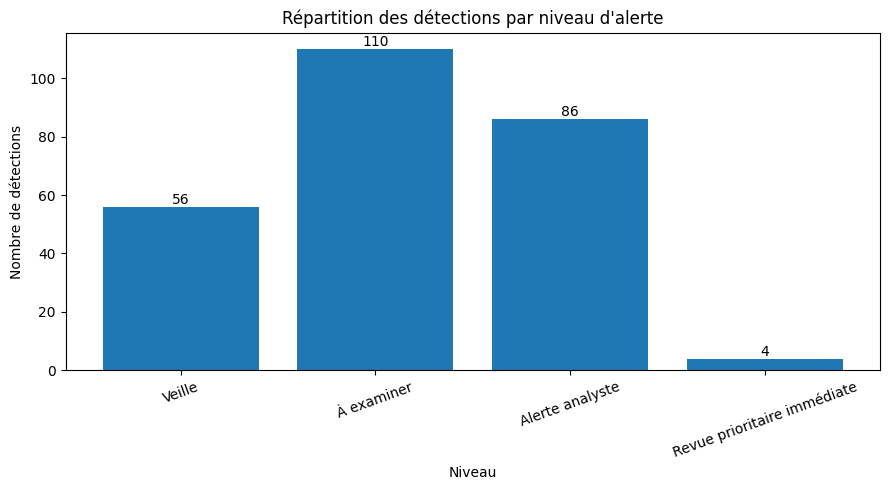

In [18]:
alert_counts = scored["alert_level"].value_counts().reindex([
    "Veille", "À examiner", "Alerte analyste", "Revue prioritaire immédiate"
], fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(alert_counts.index, alert_counts.values)
ax.set_title("Répartition des détections par niveau d'alerte")
ax.set_xlabel("Niveau")
ax.set_ylabel("Nombre de détections")
ax.tick_params(axis="x", rotation=20)

for bar, value in zip(bars, alert_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

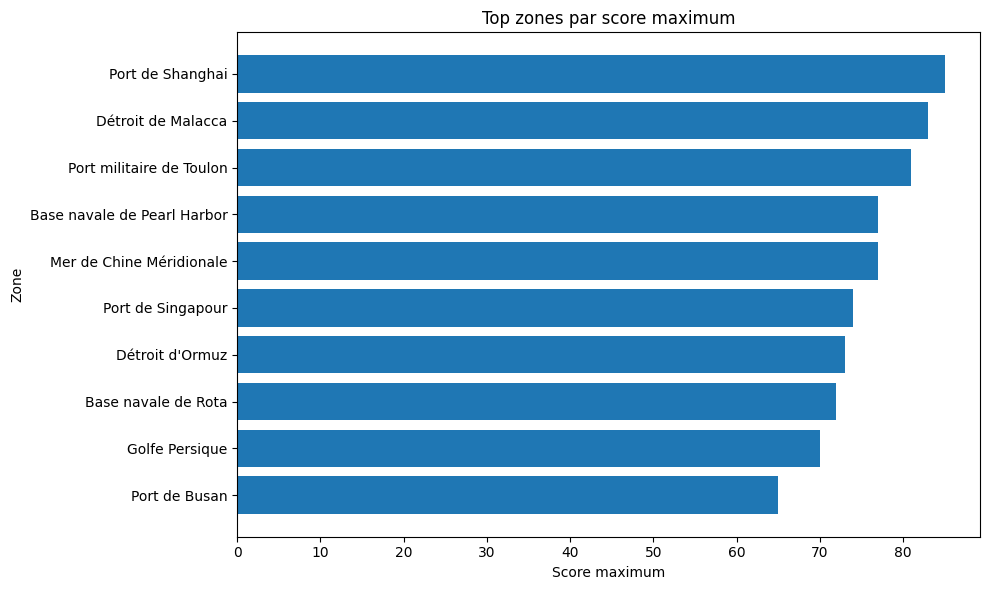

In [19]:
top_zones = zone_summary.head(10).sort_values("max_priority_score")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_zones["zone_name"], top_zones["max_priority_score"])
ax.set_title("Top zones par score maximum")
ax.set_xlabel("Score maximum")
ax.set_ylabel("Zone")
plt.tight_layout()
plt.show()

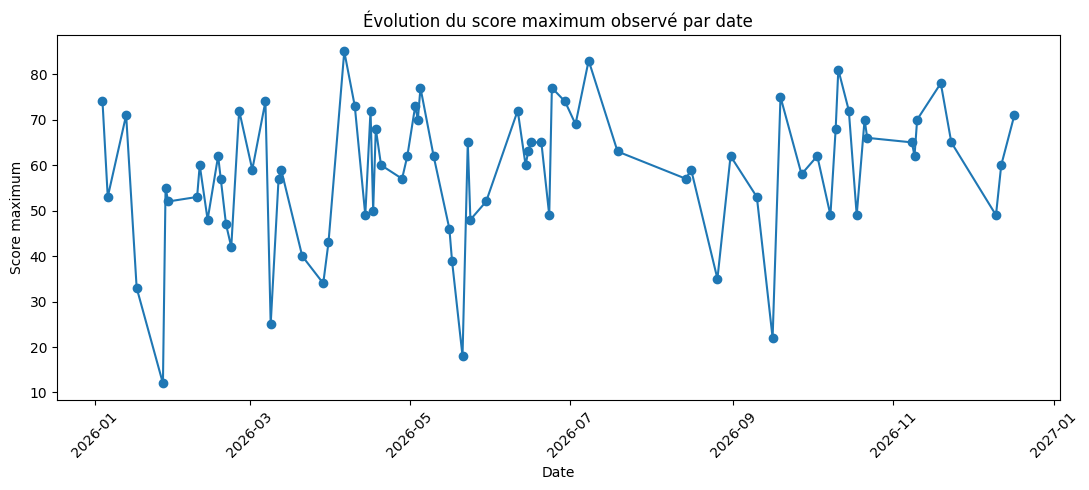

In [20]:
daily_global = (
    daily_zone_summary
    .groupby("date_only")
    .agg(
        detections=("detections", "sum"),
        human_reviews=("human_reviews", "sum"),
        max_priority_score=("max_priority_score", "max"),
    )
    .reset_index()
    .sort_values("date_only")
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily_global["date_only"], daily_global["max_priority_score"], marker="o")
ax.set_title("Évolution du score maximum observé par date")
ax.set_xlabel("Date")
ax.set_ylabel("Score maximum")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

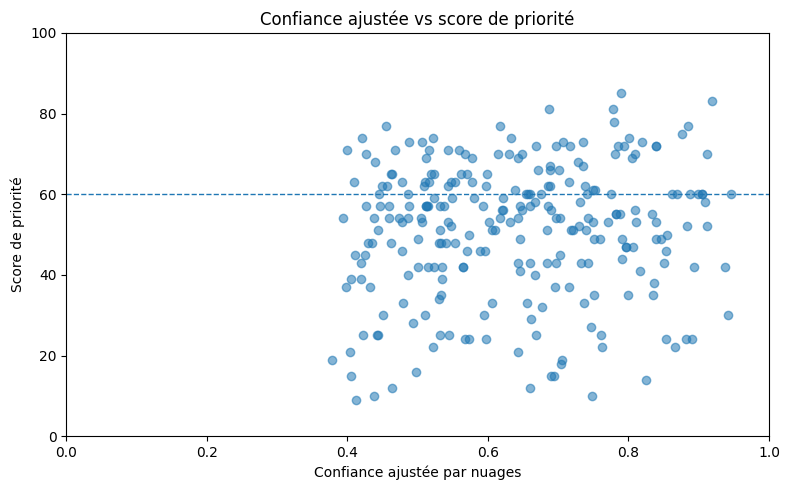

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(scored["adjusted_confidence"], scored["priority_score"], alpha=0.55)
ax.axhline(REVIEW_THRESHOLD, linestyle="--", linewidth=1)
ax.set_title("Confiance ajustée vs score de priorité")
ax.set_xlabel("Confiance ajustée par nuages")
ax.set_ylabel("Score de priorité")
ax.set_xlim(0, 1)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 15 — Export des résultats

Les fichiers générés sont prêts pour une reprise dans :

- une présentation ;
- une app Streamlit/Dash ;
- une carte Leaflet/Folium ;
- un tableau de briefing.

In [22]:
# Colonnes principales pour éviter un export illisible
core_columns = [
    "detection_id", "image_id", "file_name", "image_datetime", "date_only",
    "category", "vessel_group", "confidence", "cloud_cover", "adjusted_confidence",
    "quality_score", "quality_level",
    "bbox", "bbox_ratio", "bbox_area_pct", "bbox_inside_image", "bbox_plausibility",
    "classification_uncertainty_flag",
    "zone_name", "country", "image_lat", "image_lon",
    "detection_risk_level", "mil_risk_level", "effective_risk_level",
    "in_sensitive_military_zone", "mil_zone_active", "base_type", "mil_density",
    "nearest_sensitive_zone", "nearest_sensitive_zone_distance_km", "near_sensitive_zone_25km",
    "same_image_detection_count", "same_image_combat_count", "same_image_civilian_count",
    "same_zone_day_detection_count", "same_zone_day_combat_count", "same_zone_day_civilian_count",
    "possible_co_presence_proxy", "dense_activity_same_day",
    "zone_observation_days", "zone_observation_span_days",
    "score_vessel", "score_geo", "score_context", "score_confidence", "score_anomaly",
    "priority_score", "alert_level", "requires_human_review", "review_reasons", "scoring_version",
]

existing_core_columns = [col for col in core_columns if col in scored.columns]

scored_export = scored[existing_core_columns].copy()
human_review_export = human_review[existing_core_columns].copy()

scored_path = OUTPUT_DIR / "scored_detections_v2.csv"
human_review_path = OUTPUT_DIR / "human_review_required_v2.csv"
top10_path = OUTPUT_DIR / "top10_alerts_briefing_v2.csv"
zone_summary_path = OUTPUT_DIR / "zone_summary_v2.csv"
daily_zone_summary_path = OUTPUT_DIR / "daily_zone_summary_v2.csv"

scored_export.to_csv(scored_path, index=False)
human_review_export.to_csv(human_review_path, index=False)
top10_alerts[existing_core_columns].to_csv(top10_path, index=False)
zone_summary.to_csv(zone_summary_path, index=False)
daily_zone_summary.to_csv(daily_zone_summary_path, index=False)

print("Exports générés :")
for path in [scored_path, human_review_path, top10_path, zone_summary_path, daily_zone_summary_path]:
    print(f"- {path.resolve()}")

Exports générés :
- /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2/scored_detections_v2.csv
- /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2/human_review_required_v2.csv
- /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2/top10_alerts_briefing_v2.csv
- /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2/zone_summary_v2.csv
- /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2/daily_zone_summary_v2.csv


## 16 — Carte HTML interactive par zone

Cette carte agrège par zone pour éviter de superposer 30 marqueurs au même point.

Elle est pensée pour la présentation hiérarchique :

- taille du point = volume de revues humaines ;
- couleur = niveau d'alerte maximum ;
- popup = résumé opérationnel et principaux signaux.

La carte rappelle explicitement que les points ne sont pas des positions GPS exactes de navires.

In [23]:
def build_alert_map(zone_summary_df: pd.DataFrame, scored_df: pd.DataFrame, output_path: Path):
    try:
        import folium
    except ImportError:
        print("folium n'est pas installé : carte non générée.")
        return None

    valid_zones = zone_summary_df.dropna(subset=["image_lat", "image_lon"]).copy()
    if valid_zones.empty:
        print("Aucune coordonnée valide pour générer la carte.")
        return None

    center_lat = valid_zones["image_lat"].mean()
    center_lon = valid_zones["image_lon"].mean()

    alert_colors = {
        "Veille": "gray",
        "À examiner": "orange",
        "Alerte analyste": "red",
        "Revue prioritaire immédiate": "darkred",
    }

    m = folium.Map(location=[center_lat, center_lon], zoom_start=2, tiles="OpenStreetMap")

    title_html = """
    <div style="
        position: fixed;
        top: 10px;
        left: 50px;
        z-index: 9999;
        background-color: white;
        padding: 12px;
        border: 1px solid #999;
        border-radius: 4px;
        font-family: Arial;
        max-width: 520px;
        box-shadow: 0 1px 4px rgba(0,0,0,0.3);
    ">
    <b>Priorisation des observations navales — scoring analyste v2</b><br>
    Les points représentent des zones d'observation, pas la position GPS exacte des navires.<br>
    Le score sert à prioriser la revue humaine, pas à mesurer une menace réelle.
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    legend_html = """
    <div style="
        position: fixed;
        bottom: 30px;
        left: 50px;
        z-index: 9999;
        background-color: white;
        padding: 10px;
        border: 1px solid #999;
        border-radius: 4px;
        font-family: Arial;
        line-height: 1.5;
        box-shadow: 0 1px 4px rgba(0,0,0,0.3);
    ">
    <b>Légende</b><br>
    <span style="color: darkred;">●</span> Revue prioritaire immédiate<br>
    <span style="color: red;">●</span> Alerte analyste<br>
    <span style="color: orange;">●</span> À examiner<br>
    <span style="color: gray;">●</span> Veille<br>
    Taille du point : volume d'alertes à revue humaine
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    for _, zone in valid_zones.iterrows():
        zone_name = zone["zone_name"]
        zone_alert_level = zone["max_alert_level"]
        color = alert_colors.get(zone_alert_level, "blue")
        radius = 6 + min(20, float(zone["human_reviews"]))

        top_zone_detections = (
            scored_df[scored_df["zone_name"] == zone_name]
            .sort_values(["priority_score", "quality_score"], ascending=[False, False])
            .head(5)
        )

        top_items = "".join([
            f"<li>{r.detection_id} — {r.category} — score {r.priority_score} — {r.alert_level}</li>"
            for r in top_zone_detections.itertuples()
        ])

        popup_html = f"""
        <div style="font-family: Arial; width: 360px;">
            <h4>{zone_name}</h4>
            <b>Risque effectif :</b> {zone['effective_risk_level']}<br>
            <b>Niveau max :</b> {zone_alert_level}<br>
            <b>Score max :</b> {zone['max_priority_score']}<br>
            <b>Détections :</b> {zone['detections']}<br>
            <b>Revues humaines :</b> {zone['human_reviews']}<br>
            <b>Navires de combat :</b> {zone['combat_detections']}<br>
            <b>Navires civils :</b> {zone['civilian_detections']}<br>
            <b>Jours observés :</b> {zone['observation_days']}<br>
            <b>Première observation :</b> {zone['first_observation']}<br>
            <b>Dernière observation :</b> {zone['last_observation']}<br>
            <hr>
            <b>Top observations :</b>
            <ol>{top_items}</ol>
        </div>
        """

        folium.CircleMarker(
            location=[zone["image_lat"], zone["image_lon"]],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.65,
            popup=folium.Popup(popup_html, max_width=420),
            tooltip=f"{zone_name} — score max {zone['max_priority_score']} — {zone_alert_level}",
        ).add_to(m)

    m.save(output_path)
    return output_path

map_path = OUTPUT_DIR / "alert_map_v2.html"
generated_map = build_alert_map(zone_summary, scored, map_path)

if generated_map:
    print(f"Carte générée : {generated_map.resolve()}")

Carte générée : /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2/alert_map_v2.html


## 17 — Préparation à une future version interactive

La table `daily_zone_summary_v2.csv` est volontairement construite pour afficher :

- l'évolution du score par date ;
- les zones qui montent en priorité ;
- les périodes d'activité dense ;
- les co-présences potentielles.

La fonction suivante donne une base simple pour filtrer les alertes dans une future app.

In [24]:
def filter_alerts(
    data: pd.DataFrame,
    start_date=None,
    end_date=None,
    zones=None,
    alert_levels=None,
    min_score=None,
    only_human_review=False,
):
    filtered = data.copy()

    if start_date is not None:
        filtered = filtered[pd.to_datetime(filtered["date_only"]) >= pd.to_datetime(start_date)]

    if end_date is not None:
        filtered = filtered[pd.to_datetime(filtered["date_only"]) <= pd.to_datetime(end_date)]

    if zones is not None:
        zones = [zones] if isinstance(zones, str) else list(zones)
        filtered = filtered[filtered["zone_name"].isin(zones)]

    if alert_levels is not None:
        alert_levels = [alert_levels] if isinstance(alert_levels, str) else list(alert_levels)
        filtered = filtered[filtered["alert_level"].isin(alert_levels)]

    if min_score is not None:
        filtered = filtered[filtered["priority_score"] >= min_score]

    if only_human_review:
        filtered = filtered[filtered["requires_human_review"]]

    return filtered.sort_values(["priority_score", "quality_score"], ascending=[False, False])

# Exemple : alertes analyste et revues prioritaires uniquement
example_filtered = filter_alerts(
    scored,
    alert_levels=["Alerte analyste", "Revue prioritaire immédiate"],
    only_human_review=True,
)

display(example_filtered[[
    "detection_id", "date_only", "zone_name", "category",
    "priority_score", "quality_score", "alert_level", "review_reasons"
]].head(10))

,detection_id,date_only,zone_name,category,priority_score,quality_score,alert_level,review_reasons
26,DET-007-00027,2026-04-06,Port de Shanghai,Destroyer,85,73,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
72,DET-022-00073,2026-07-08,Détroit de Malacca,Destroyer,83,82,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
181,DET-067-00182,2026-10-11,Port militaire de Toulon,Sous-marin,81,72,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
22,DET-007-00023,2026-04-06,Port de Shanghai,Croiseur,81,66,Revue prioritaire immédiate,navire de combat stratégique; zone critique; z...
235,DET-091-00236,2026-11-19,Détroit de Malacca,Destroyer,78,73,Alerte analyste,navire de combat stratégique; zone critique; z...
107,DET-034-00108,2026-06-24,Mer de Chine Méridionale,Sous-marin,77,77,Alerte analyste,navire de combat stratégique; zone critique; a...
179,DET-067-00180,2026-10-11,Port militaire de Toulon,Destroyer,77,61,Alerte analyste,navire de combat stratégique; zone critique; z...
217,DET-085-00218,2026-05-05,Base navale de Pearl Harbor,Croiseur,77,50,Alerte analyste,navire de combat stratégique; zone critique; z...
99,DET-031-00100,2026-09-19,Détroit de Malacca,Frégate,75,91,Alerte analyste,navire de combat; zone critique; zone militair...
21,DET-006-00022,2026-01-04,Détroit de Malacca,Porte-avions,74,84,Alerte analyste,navire de combat stratégique; zone critique; z...


In [25]:
# Optionnel : aperçu Plotly pour une future interface.
# Laissez ENABLE_PLOTLY_PREVIEW à False pour éviter d'alourdir le notebook sur GitHub.
ENABLE_PLOTLY_PREVIEW = False

if ENABLE_PLOTLY_PREVIEW:
    try:
        import plotly.express as px

        fig = px.line(
            daily_zone_summary.sort_values("date_only"),
            x="date_only",
            y="max_priority_score",
            color="zone_name",
            markers=True,
            title="Évolution du score maximum par zone et par date",
        )
        fig.show()
    except ImportError:
        print("plotly n'est pas installé.")
else:
    print("Aperçu Plotly désactivé. Passez ENABLE_PLOTLY_PREVIEW à True pour l'activer.")

Aperçu Plotly désactivé. Passez ENABLE_PLOTLY_PREVIEW à True pour l'activer.


## 18 — Résumé final

À retenir pour la présentation :

1. Les sorties de détection sont déjà fournies.
2. Le notebook transforme ces sorties en une liste d'alertes priorisées.
3. Le score est explicable et versionné.
4. Les raisons de revue humaine sont écrites en clair.
5. La carte est une aide à la décision par zone, pas une carte tactique.
6. Les exports sont prêts pour une future version interactive.

In [26]:
summary = {
    "detections_analysees": len(scored),
    "revues_humaines": int(scored["requires_human_review"].sum()),
    "zones_observees": int(scored["zone_name"].nunique()),
    "score_max": int(scored["priority_score"].max()),
    "score_moyen": round(float(scored["priority_score"].mean()), 1),
    "qualite_moyenne": round(float(scored["quality_score"].mean()), 1),
    "version_scoring": SCORING_VERSION,
}

print("=== RÉSUMÉ ACTIONNABLE ===")
for key, value in summary.items():
    print(f"{key}: {value}")

print("\nTop 5 zones à regarder :")
display(zone_summary[[
    "zone_name", "detections", "human_reviews", "max_priority_score",
    "max_alert_level", "effective_risk_level", "observation_days"
]].head(5))

print("\nFichiers générés dans :", OUTPUT_DIR.resolve())

=== RÉSUMÉ ACTIONNABLE ===
detections_analysees: 256
revues_humaines: 112
zones_observees: 15
score_max: 85
score_moyen: 51.2
qualite_moyenne: 66.4
version_scoring: v2.1-actionnable

Top 5 zones à regarder :


,zone_name,detections,human_reviews,max_priority_score,max_alert_level,effective_risk_level,observation_days
12,Port de Shanghai,18,13,85,Revue prioritaire immédiate,Critical,5
6,Détroit de Malacca,38,31,83,Revue prioritaire immédiate,Critical,11
14,Port militaire de Toulon,10,8,81,Revue prioritaire immédiate,Critical,2
9,Mer de Chine Méridionale,30,9,77,Alerte analyste,Critical,8
1,Base navale de Pearl Harbor,6,4,77,Alerte analyste,Critical,2



Fichiers générés dans : /Users/Louis/Documents/Ecole/Etudes Sup/Albert/Cours/B2/BDD/8.Hackaton Marine Nationale/Sujet5/Généralisation/outputs_priorisation_v2
